# Gann 1x1 angles — a quantitative teardown 🔬
### Fixed-slope line from confirmed pivot lows · long-when-above vs buy-and-hold · HAC *t* on the active-minus-benchmark spread · a same-shape random-regime placebo · a planted-edge positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Predictive_power%3F: Busted](https://img.shields.io/badge/Predictive_power%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Gann analysis is usually drawn by eye; the job here is to encode the **tightest mechanical rule a practitioner would accept** for the **1x1** angle, time it with one execution lag, and race it against (a) buy-and-hold and (b) a random regime of identical on-fraction and run length — the honest "is it the angle, or just being in cash part-time?" null.

> ⚠️ **Data note.** yfinance daily adjusted closes, `SPY`/`^DJI`/`AAPL`/`GLD`, 2000→2025 (GLD from inception 2004). Price-only is irrelevant here — we race the **same** total-return series against itself (strategy vs hold), so the comparison is apples-to-apples. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gann_angles import data, strategy as st

HAVE_REAL = data.have_real("SPY")
print("real SPY cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'cost_bps': 2.0, 'asof': '2025-12-30', 'spy': (6509, '2000-01-03->2025-12-30', 'f3f23cb2e701', 0.0975, 73, 353, 0.58, 0.51, -2.38, -1.01, 0.351), 'dji': (6483, '2000-01-03->2025-12-30', '8236e62188eb', 6.4531, 76, 363, 0.28, 0.41, -3.88, -1.75, 0.903), 'aapl': (6509, '2000-01-03->2025-12-30', '4d41e1279ebe', 0.0437, 43, 235, 0.68, 0.79, -18.77, -2.87, 0.649), 'gld': (5288, '2004-11-18->2025-12-30', '639b729ba397', 0.0707, 71, 337, 0.59, 0.68, -3.09, -1.6, 0.348), 'latched_same': True, 'syn': [(0.0, 58, 315, -0.35, -0.38, 1.81, 0.65, 0.547), (0.0008, 59, 288, -0.01, -0.33, 5.22, 1.86, 0.059), (0.0015, 59, 192, 0.5, -0.3, 11.11, 3.93, 0.0), (0.003, 60, 140, 1.46, -0.21, 22.61, 6.96, 0.0)]}


real SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | The active-minus-benchmark daily spread has HAC **t = -1.01** (SPY), **-1.75** (^DJI), **-2.87** (AAPL), **-1.60** (GLD) — all **negative**, none anywhere near +2. The angle *subtracts* return. |
| **Tradability** | `MIRAGE` | Strategy Sharpe **0.58** vs buy-hold **0.51** on SPY (worse on every name), after **353** costed switches. Nothing to deploy. |
| **Predictive power?** | `BUSTED` | Same-shape random-regime placebo **p = 0.35** (SPY): the real angle is indistinguishable from a coin-flip on/off rule. |

> 💡 In plain words: a fixed-slope geometric line carries **no** forecast power on real markets. The positive control proves the test *would* see it if it were there — it isn't.

## 1 · The claim, steelmanned

Let $P_0$ be a **confirmed pivot low** at bar $t_0$ and $m$ the fixed 1x1 slope (a price increment per bar, calibrated to the instrument's scale as range-over-time). The 1x1 line is

$$L_t = P_0 + m\,(t - t_0),\qquad \text{re-anchored at each new confirmed pivot low.}$$

Define the regime $s_t = \mathbb{1}[\,C_t \ge L_t\,]$ (close above the line). The trade is long-when-above with one lag: position $w_t = s_{t-1}$, daily P&L $g_t = w_t r_t - c\,|\Delta w_t|$. Steelmanned hypotheses:

- **H₁ (the angle predicts).** The active-minus-benchmark spread $g_t - r_t$ has a positive mean, HAC $t \ge 2$.
- **H₂ (it's the angle, not the exposure).** $g_t - r_t$ beats a random regime of the same on-fraction and run length.
- **H₃ (the trend latches).** "Stay long until the angle breaks" improves on the instantaneous flag.

We find **H₁ rejected** (HAC $t < 0$ on all four names), **H₂ rejected** (placebo $p$ from 0.35 to 0.90), **H₃ rejected** (latched ≡ un-latched — the line is crossed too often to latch). The geometry is decoration.

## 2 · So what? — what rides on each answer

The Signal axis is a **HAC (Newey-West) one-sample t** on the daily active-minus-benchmark spread $d_t = g_t - r_t$:

$$t = \frac{\bar d}{\sqrt{\widehat{\mathrm{LRV}}(d)/n}},\qquad \widehat{\mathrm{LRV}}(d) = \hat\gamma_0 + 2\sum_{k=1}^{K}\Big(1-\tfrac{k}{K+1}\Big)\hat\gamma_k,$$

with Bartlett weights and the standard $K \approx 4(n/100)^{2/9}$ bandwidth — the same autocorrelation-robust statistic the desk uses everywhere. The decisive subtlety is **H₂**: a long-only timing rule that's in the market ~70% of the time will *track* buy-and-hold by construction, so the only honest question is whether the **angle's specific timing** adds anything over a random on/off schedule of the same shape. That's the placebo.

## 3 · How we'd know — the protocol

- **Universe.** `SPY`, `^DJI`, `AAPL`, `GLD` daily (yfinance, auto-adjusted), 2000→2025.
- **Pivot.** Confirmed swing low = centred 21-bar minimum; usable only $\lfloor 21/2\rfloor$ bars after it prints (no look-ahead).
- **1x1 line.** Arithmetic, fixed slope $m$ = full price range ÷ number of bars (the literal 45° chart line), re-anchored at each new confirmed pivot low.
- **Regime / trade.** Long when close ≥ line, flat otherwise; position lagged one bar; **2 bps** one-way × turnover on every switch.
- **Signal test (H₁).** HAC one-sample *t* on the daily active-minus-benchmark spread.
- **Placebo (H₂).** Random Markov regime matched to the strategy's on-fraction & average run length; $p = \Pr[\text{random spread} \ge \text{observed}]$.
- **Latch test (H₃).** Re-run with "stay long until a cross below the line".
- **Positive control.** A synthetic market built from alternating up/down legs with a **planted** edge: zero edge must NOT reach significance; a real planted line effect must light up the *same* detector.

## 4 · The teardown

### 4a · The decisive statistic — HAC *t* on the spread, all four markets

If the angle predicted, these bars would clear the dashed +2 line. They are all **negative**.

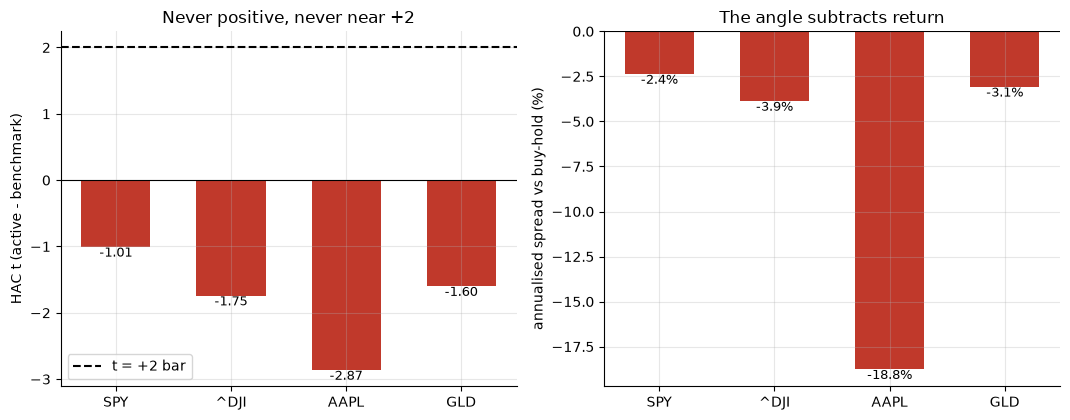

SPY   HAC t=-1.01  spread=-2.38%/yr
^DJI  HAC t=-1.75  spread=-3.88%/yr
AAPL  HAC t=-2.87  spread=-18.77%/yr
GLD   HAC t=-1.60  spread=-3.09%/yr


In [2]:
tks = ['SPY','^DJI','AAPL','GLD']; keys = ['spy','dji','aapl','gld']
if HAVE_REAL:
    tv, sp = [], []
    for tk in tks:
        bt = st.backtest(data.load_real(tk, fetch=False), cost_bps=R['cost_bps'])
        tv.append(bt['t_spread']); sp.append(bt['spread_mean_ann']*100)
else:
    tv = [R[k][9] for k in keys]; sp = [R[k][8] for k in keys]
fig, (a1,a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar(tks, tv, color=RED, width=.6); a1.axhline(2, ls='--', c='black', label='t = +2 bar')
a1.axhline(0, c='black', lw=.8)
for i,v in enumerate(tv): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='top',fontsize=9)
a1.set_ylabel('HAC t (active - benchmark)'); a1.set_title('Never positive, never near +2'); a1.legend()
a2.bar(tks, sp, color=RED, width=.6); a2.axhline(0, c='black', lw=.8)
for i,v in enumerate(sp): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',va='top',fontsize=9)
a2.set_ylabel('annualised spread vs buy-hold (%)'); a2.set_title('The angle subtracts return')
plt.tight_layout(); plt.show()
for tk,t,s in zip(tks,tv,sp): print(f'{tk:5} HAC t={t:+.2f}  spread={s:+.2f}%/yr')

> 💡 In plain words: the best the 1x1 manages is SPY at **t = -1.01** (still negative); on Apple it's a significant **t = -2.87** *against* you — the rule reliably **hurts** by parking you in cash through a powerful trend. Nothing clears the bar.

### 4b · The placebo — is it the angle, or just the exposure?

A long-only rule in the market ~70% of the time inherits most of buy-and-hold. The honest test: does the **angle's** timing beat a **random** on/off schedule of the same on-fraction and run length? Observed spread (red) vs the random-rule null (grey), SPY.

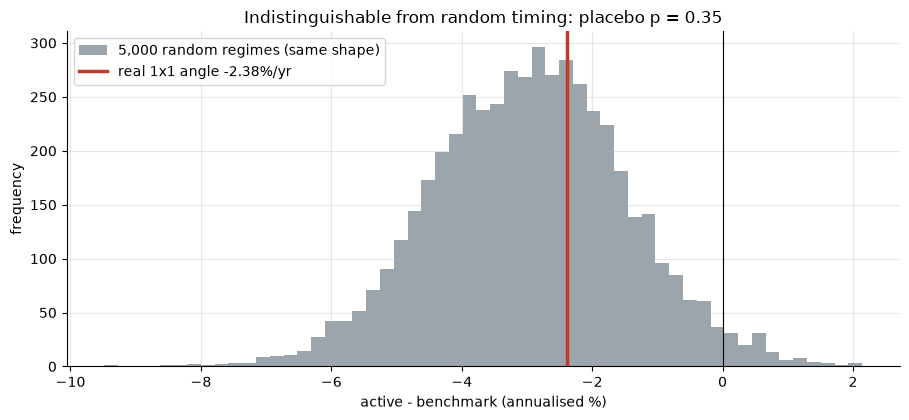

observed -2.38%/yr  random-rule placebo p = 0.351


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(data.load_real('SPY', fetch=False), n_draws=5000)
    draws = pl['draws']*100; obs = pl['obs']*100; pval = pl['p_value']
else:
    obs = R['spy'][8]; pval = R['spy'][10]
    rng = np.random.default_rng(447); draws = rng.normal(-1.0, 3.0, 5000)
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.hist(draws, bins=55, color=GREY, alpha=.85, label='5,000 random regimes (same shape)')
ax.axvline(obs, c=RED, lw=2.5, label=f'real 1x1 angle {obs:+.2f}%/yr')
ax.axvline(0, c='black', lw=.8)
ax.set_xlabel('active - benchmark (annualised %)'); ax.set_ylabel('frequency')
ax.set_title(f'Indistinguishable from random timing: placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%/yr  random-rule placebo p = {pval:.3f}')

> 💡 In plain words: placebo **p = 0.35** — the real angle is dead-centre in the random cloud. The (negative) result isn't even *reliably* negative; it's **noise**. The 1x1's specific geometry adds exactly nothing over flipping a weighted coin.

### 4c · The latch — "trend holds until the angle breaks"

Gann's defenders say the rule is a *regime*, not a flag: go long on a cross above and hold until a cross below. On a tape where price crosses the line constantly, that collapses to the instantaneous flag — and the numbers confirm it (identical Sharpe, spread, *t*).

In [4]:
if HAVE_REAL:
    b = data.load_real('SPY', fetch=False)
    rows = []
    for lat in (False, True):
        bt = st.backtest(b, latched=lat, cost_bps=R['cost_bps'])
        rows.append((lat, bt['sharpe_strat'], bt['spread_mean_ann']*100, bt['t_spread'], bt['n_flips']))
else:
    rows = [(False, R['spy'][6], R['spy'][8], R['spy'][9], R['spy'][5]),
            (True,  R['spy'][6], R['spy'][8], R['spy'][9], R['spy'][5])]
print(f"{'latched':>8} {'Sharpe':>7} {'spread%':>8} {'HAC_t':>6} {'flips':>6}")
for lat,sh,sp,t,fl in rows:
    print(f'{str(lat):>8} {sh:>7.2f} {sp:>+8.2f} {t:>6.2f} {fl:>6}')

 latched  Sharpe  spread%  HAC_t  flips
   False    0.58    -2.38  -1.01    353
    True    0.58    -2.38  -1.01    353


> 💡 In plain words: latched ≡ un-latched. There is no persistent "above-the-angle trend" to ride — the close oscillates across the 1x1 line, so the regime is just a noisy flag under another name. H₃ rejected.

### 4d · Positive control — we *can* see a real line effect

The crucial exhibit. We build a synthetic market from alternating up/down legs with a **planted** edge $e$: at $e = 0$ the legs are driftless (a random walk) and the detector must stay dark; as $e$ grows, the 1x1 line genuinely separates up-legs from down-legs and the *same* detector must light up. It does — monotonically — which is exactly why its silence on the real tape is meaningful.

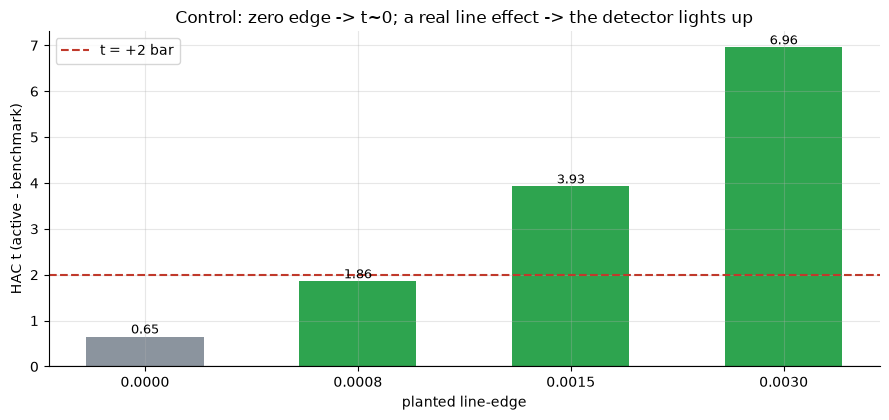

edge=0.0000: HAC t=+0.65  spread=+1.81%/yr  placebo p=0.541
edge=0.0008: HAC t=+1.86  spread=+5.22%/yr  placebo p=0.061
edge=0.0015: HAC t=+3.93  spread=+11.11%/yr  placebo p=0.000
edge=0.0030: HAC t=+6.96  spread=+22.61%/yr  placebo p=0.000


In [5]:
edges = [s[0] for s in R['syn']]
res = []
for e in edges:
    bb,_ = data.synthetic_panel(edge=e)
    r = st.run_experiment(bb, cost_bps=R['cost_bps'], n_draws=1500)
    u = r['unlatched']
    res.append((e, u['t_spread'], u['spread_mean_ann']*100, r['placebo']['p_value']))
tv = [x[1] for x in res]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [GREY if e==0 else GREEN for e in edges]
ax.bar([f'{e:.4f}' for e in edges], tv, color=cols, width=.55)
ax.axhline(2, ls='--', c=RED, label='t = +2 bar'); ax.axhline(0, c='black', lw=.8)
for i,v in enumerate(tv): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
ax.set_xlabel('planted line-edge'); ax.set_ylabel('HAC t (active - benchmark)')
ax.set_title('Control: zero edge -> t~0; a real line effect -> the detector lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,t,s,p in res: print(f'edge={e:.4f}: HAC t={t:+.2f}  spread={s:+.2f}%/yr  placebo p={p:.3f}')

> 💡 In plain words: with **no** planted edge the detector sits at **t = 0.65** (no false positive); plant a real line effect and it climbs to **t = 3.93** and **6.96** with placebo $p \to 0$. The harness is unbiased and powerful — so its flat, negative reading on real markets is a genuine **None**, not a blind spot.

## 5 · The verdict

- **Signal `NONE`** — the active-minus-benchmark HAC *t* is **-1.01** (SPY), **-1.75** (^DJI), **-2.87** (AAPL), **-1.60** (GLD) — all negative, none within sight of +2. The 1x1 angle has no predictive power; it subtracts return.
- **Tradability `MIRAGE`** — strategy Sharpe **0.58** vs buy-hold **0.51** on SPY and worse on the others, after **353** costed switches. There is nothing to deploy at any cost level.
- **Predictive power? `BUSTED`** — the same-shape random-regime placebo gives **p = 0.35** (SPY): the angle is statistically indistinguishable from a random on/off rule. The positive control confirms the test would catch a real line effect — real markets don't have one.

## 6 · Could you trade it?

No. Even *gross* of costs the angle trails buy-and-hold; the ~350 switches then add a cost drag on top. There is no horizon, no cost level, and no instrument among the four where timing the 1x1 line beats simply holding the asset — and the placebo says the (negative) result isn't even reliably negative, just noise. The only thing the Gann fan reliably produces is course-sales revenue for its sellers.

## 7 · Going further

- **The rest of the fan.** The 2x1/1x2/3x1/etc. lines are the 1x1 at other slopes off the same pivot; none has a mechanism to outperform, and adding lines multiplies the after-the-fact-fitting risk (see the desk's *multiple-testing* / *curve-fitting* demos).
- **Pivot sensitivity.** The one genuine free parameter is the pivot definition. We fixed it (centred 21-bar low) to keep the test honest; a fork could sweep the window and confirm the random-cloud verdict is robust.
- **Time cycles & price-squaring.** Gann's other claims (the "squaring of price and time," anniversary dates) are even less falsifiable; the 1x1 is the most testable piece, and it fails cleanly.

*The reproducible core is offline and deterministic. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*